# 01. EDA - Online Gaming Behavior Dataset

게임 유저 행동 데이터 탐색적 분석

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 & 기본 정보

In [2]:
from src.data.loader import load_gaming_behavior, get_gaming_behavior_summary

df = load_gaming_behavior()
summary = get_gaming_behavior_summary(df)

print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}컬럼")
print(f"이탈률 (EngagementLevel=Low): {summary['churn_rate']:.2%}")
print(f"이탈 유저: {summary['churn_count']:,}명 / 유지 유저: {summary['retained_count']:,}명")
print(f"\n수치형 컬럼: {summary['numeric_columns']}")
print(f"범주형 컬럼: {summary['categorical_columns']}")
df.head()

데이터 크기: 40,034행 × 14컬럼
이탈률 (EngagementLevel=Low): 25.79%
이탈 유저: 10,324명 / 유지 유저: 29,710명

수치형 컬럼: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'is_churned']
범주형 컬럼: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,is_churned
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,0
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,0
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,0
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,0
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,0


In [3]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,is_churned
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477,0.257881
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726,0.437474
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000,0.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000,0.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000,1.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000,1.000000


In [4]:
# 결측치 확인
missing = df.isnull().sum()
print("결측치 현황:")
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음")

결측치 현황:
결측치 없음


## 2. 타겟 변수 분포 (이탈 vs 유지)

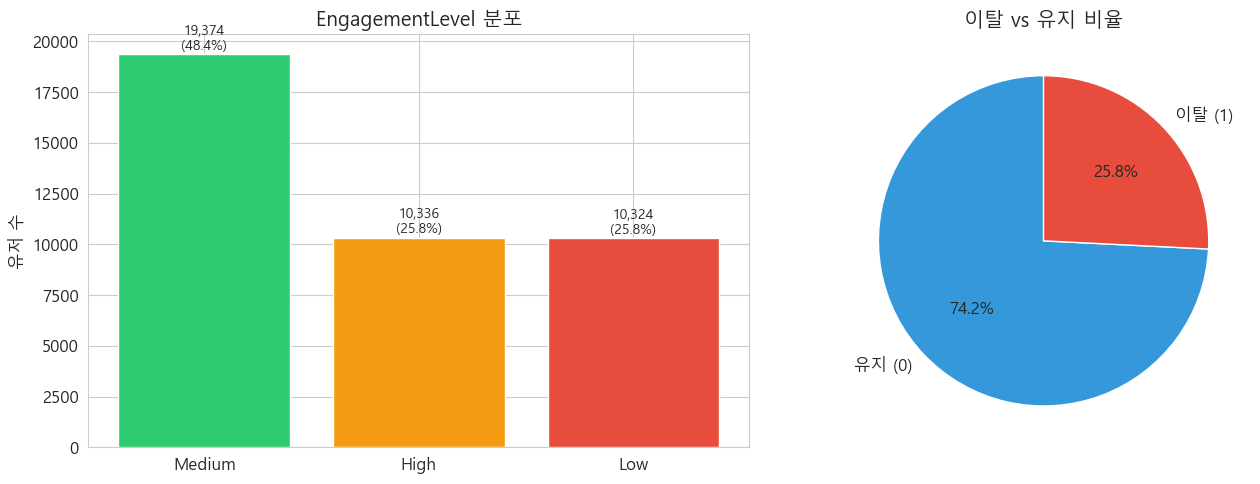

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EngagementLevel 분포
engagement_counts = df['EngagementLevel'].value_counts()
colors_engagement = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(engagement_counts.index, engagement_counts.values, color=colors_engagement)
axes[0].set_title('EngagementLevel 분포')
axes[0].set_ylabel('유저 수')
for i, (label, val) in enumerate(zip(engagement_counts.index, engagement_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)

# 이탈 여부 (이진)
churn_counts = df['is_churned'].value_counts()
colors_churn = ['#3498db', '#e74c3c']
labels_churn = ['유지 (0)', '이탈 (1)']
axes[1].pie(churn_counts.values, labels=labels_churn, colors=colors_churn,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('이탈 vs 유지 비율')

plt.tight_layout()
plt.show()

## 3. 수치형 변수 분포 (이탈 그룹별 비교)

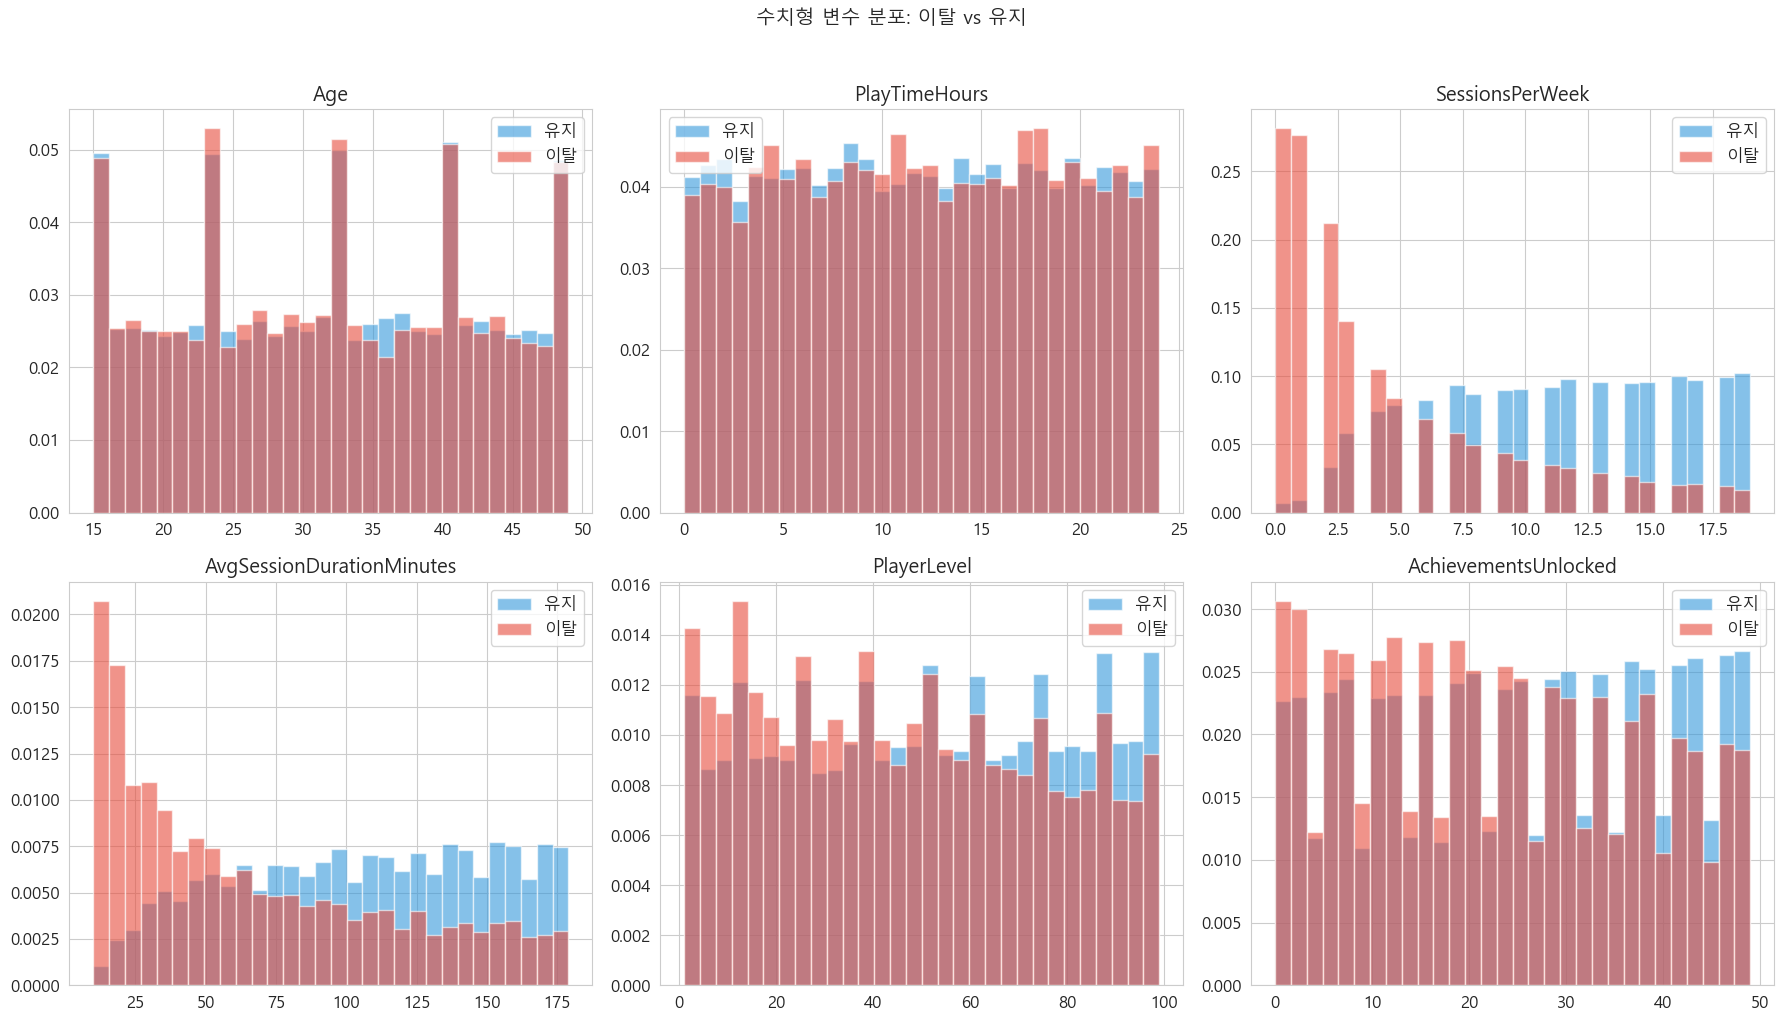

In [6]:
numeric_cols = ['Age', 'PlayTimeHours', 'SessionsPerWeek', 
                'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[df['is_churned'] == 0][col].hist(ax=ax, bins=30, alpha=0.6, label='유지', color='#3498db', density=True)
    df[df['is_churned'] == 1][col].hist(ax=ax, bins=30, alpha=0.6, label='이탈', color='#e74c3c', density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('수치형 변수 분포: 이탈 vs 유지', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:8: UserWarning: set_ticklabels() should only be used

C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\2284380413.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])


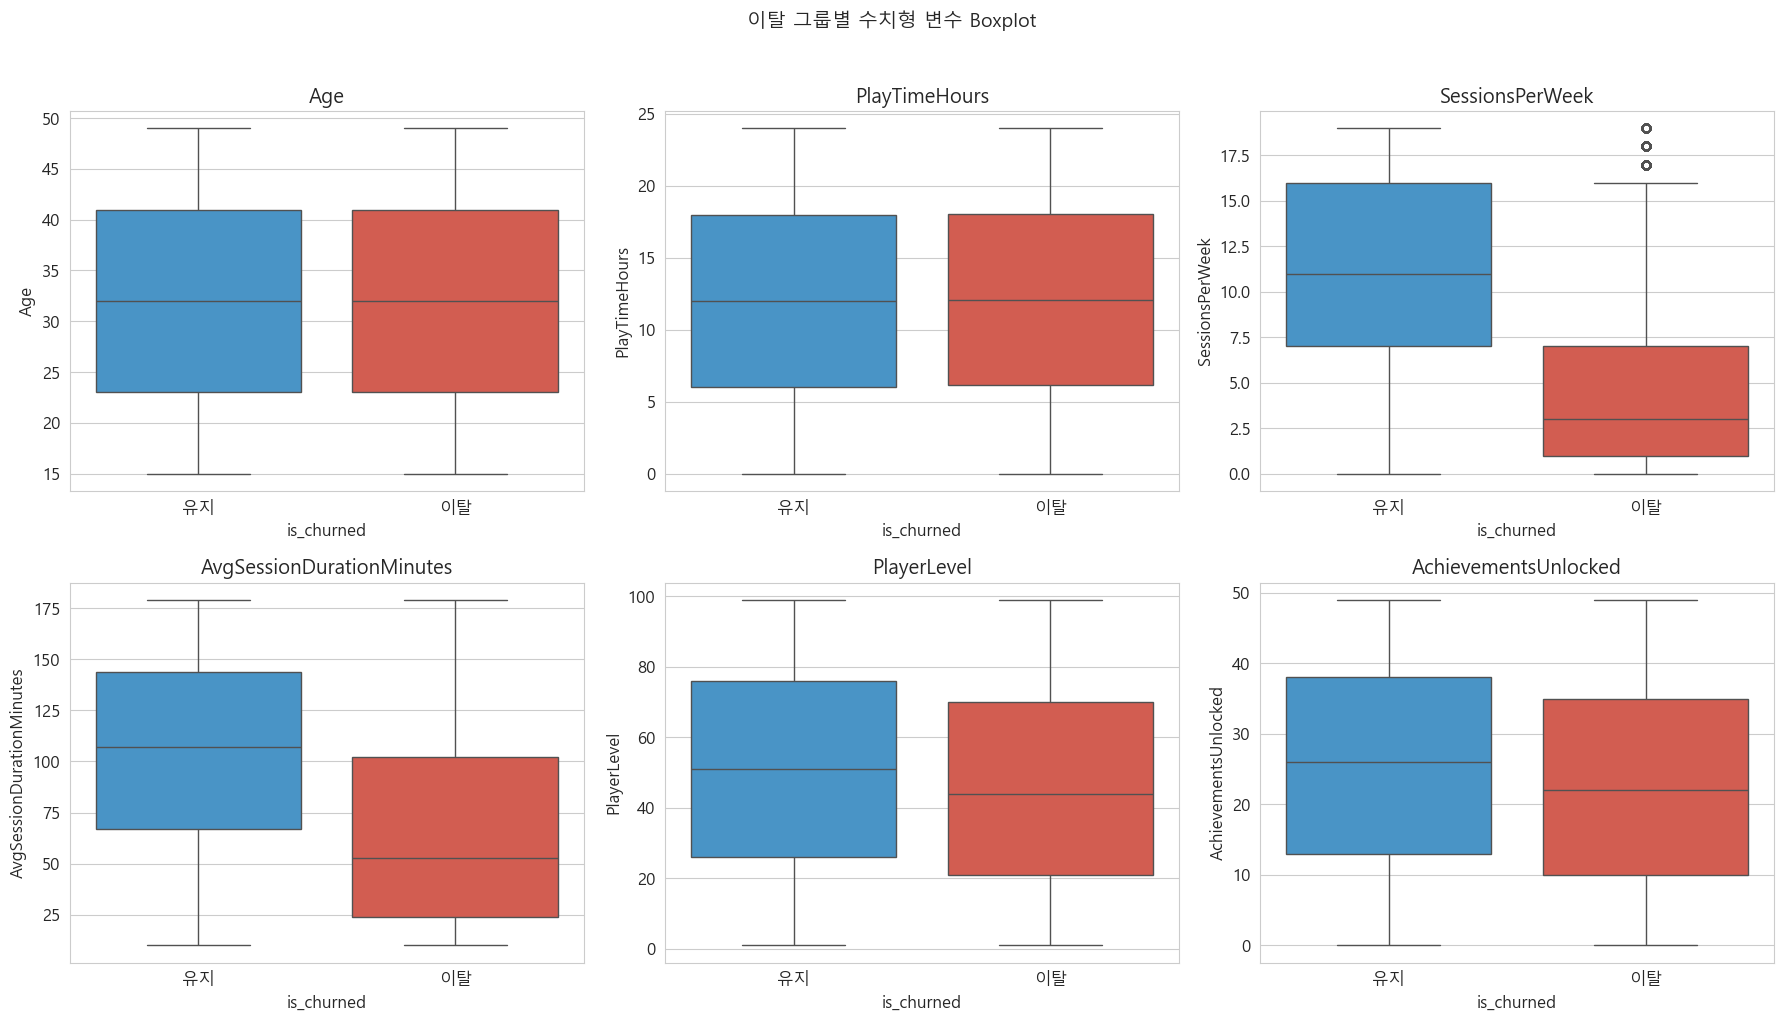

In [7]:
# 이탈 그룹별 boxplot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
    ax.set_xticklabels(['유지', '이탈'])
    ax.set_title(col)

plt.suptitle('이탈 그룹별 수치형 변수 Boxplot', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 범주형 변수 분포 (이탈 비율 비교)

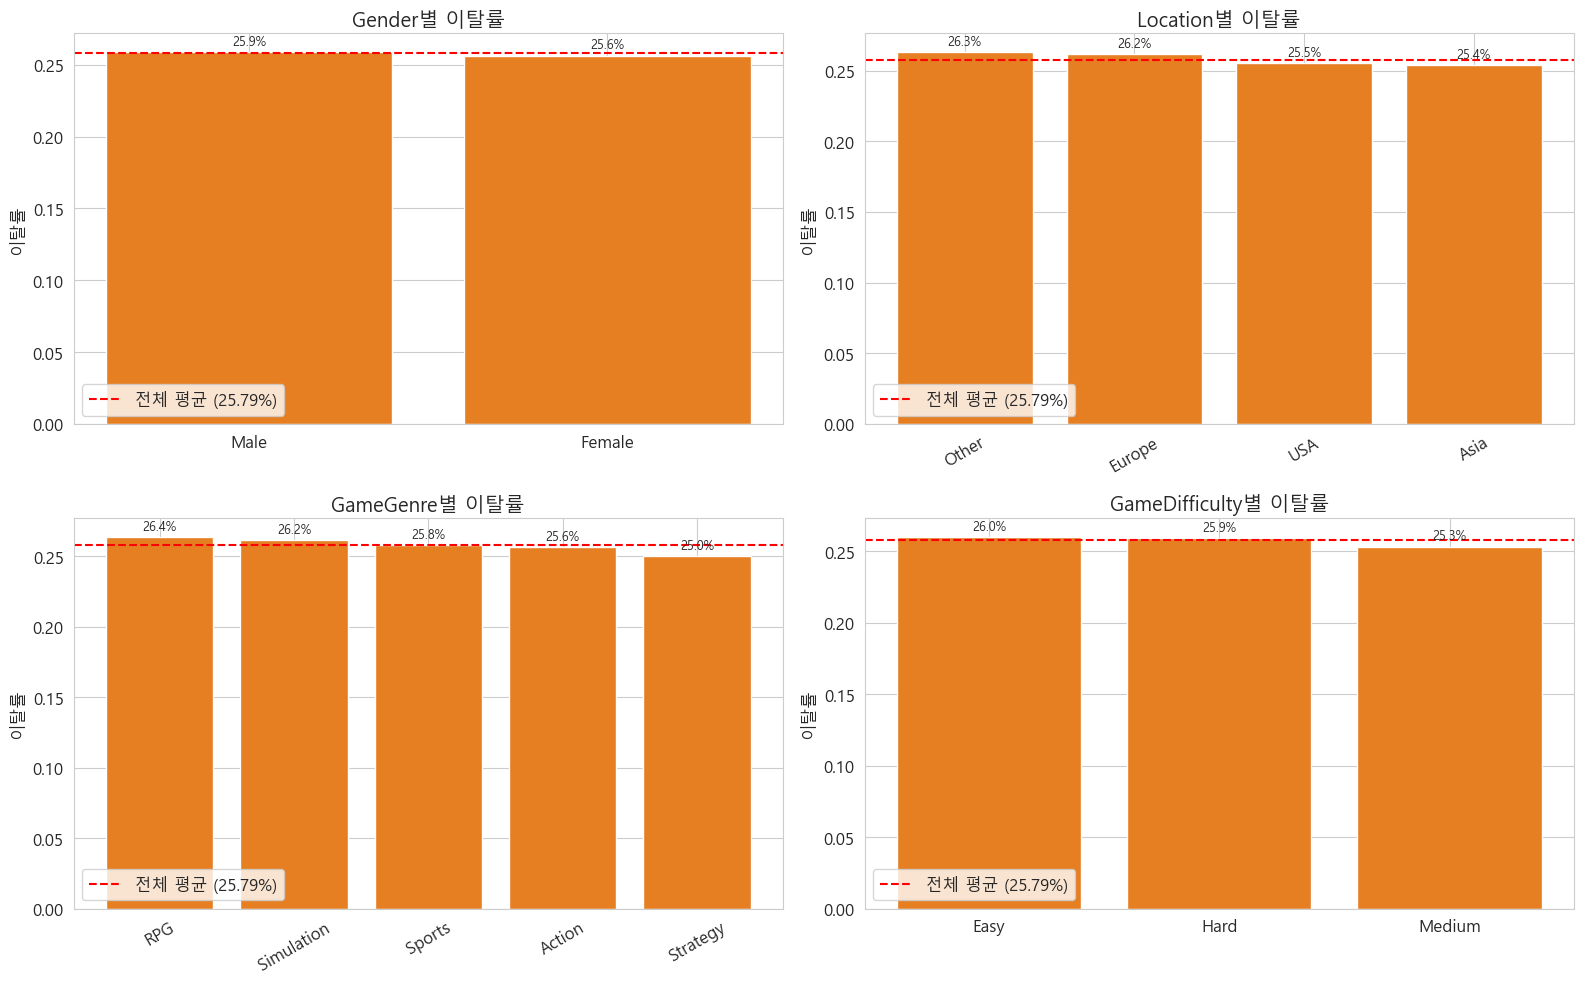

In [8]:
cat_cols = ['Gender', 'Location', 'GameGenre', 'GameDifficulty']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    churn_rate_by_cat = df.groupby(col)['is_churned'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate_by_cat.index, churn_rate_by_cat.values, color='#e67e22')
    ax.set_title(f'{col}별 이탈률')
    ax.set_ylabel('이탈률')
    ax.axhline(y=df['is_churned'].mean(), color='red', linestyle='--', label=f'전체 평균 ({df["is_churned"].mean():.2%})')
    ax.legend()
    
    for bar, val in zip(bars, churn_rate_by_cat.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.1%}', ha='center', fontsize=9)
    
    if col in ['Location', 'GameGenre']:
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. 상관관계 분석

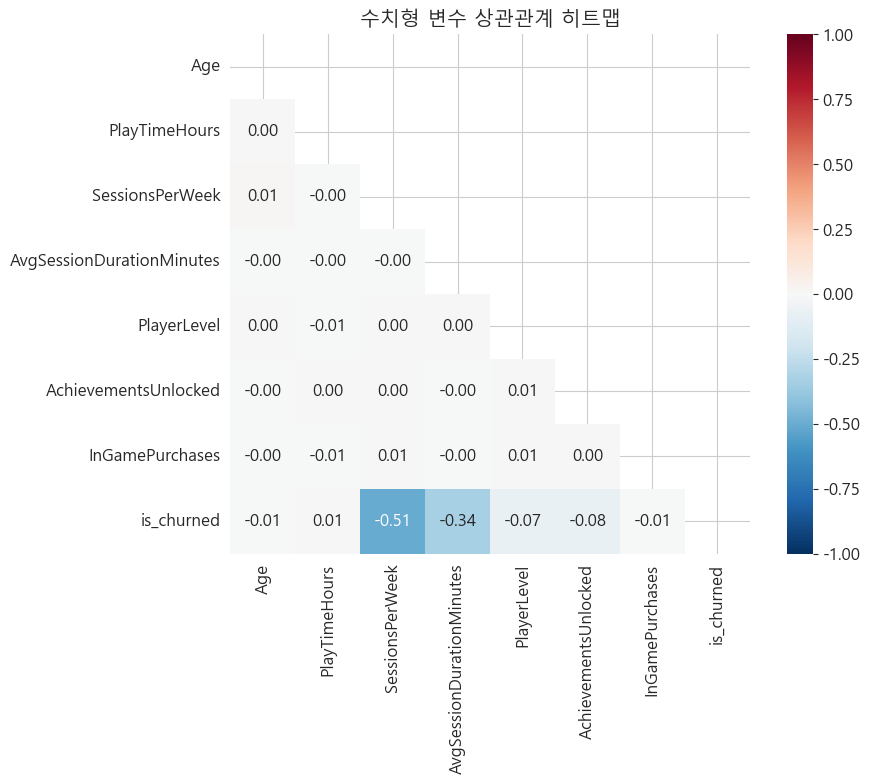

In [9]:
# 수치형 변수 상관관계 히트맵
corr_cols = numeric_cols + ['InGamePurchases', 'is_churned']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('수치형 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

In [10]:
# is_churned와의 상관관계 정렬
churn_corr = corr_matrix['is_churned'].drop('is_churned').sort_values(key=abs, ascending=False)
print("is_churned와의 상관관계 (절대값 순):")
for feat, val in churn_corr.items():
    direction = "↑ 이탈 증가" if val > 0 else "↓ 이탈 감소"
    print(f"  {feat:>30s}: {val:+.4f}  ({direction})")

is_churned와의 상관관계 (절대값 순):
                 SessionsPerWeek: -0.5054  (↓ 이탈 감소)
       AvgSessionDurationMinutes: -0.3357  (↓ 이탈 감소)
            AchievementsUnlocked: -0.0762  (↓ 이탈 감소)
                     PlayerLevel: -0.0733  (↓ 이탈 감소)
                   PlayTimeHours: +0.0069  (↑ 이탈 증가)
                             Age: -0.0056  (↓ 이탈 감소)
                 InGamePurchases: -0.0052  (↓ 이탈 감소)


## 6. 통계적 가설 검정 (이탈 vs 유지 그룹 차이)

In [11]:
# t-test: 수치형 변수가 이탈/유지 그룹 간에 통계적으로 유의한 차이가 있는지
churned = df[df['is_churned'] == 1]
retained = df[df['is_churned'] == 0]

print("=== 독립표본 t-test (이탈 vs 유지) ===\n")
print(f"{'변수':>30s} | {'유지 평균':>10s} | {'이탈 평균':>10s} | {'t-stat':>8s} | {'p-value':>10s} | 유의성")
print("-" * 100)

for col in numeric_cols:
    t_stat, p_val = stats.ttest_ind(retained[col], churned[col])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"{col:>30s} | {retained[col].mean():>10.2f} | {churned[col].mean():>10.2f} | {t_stat:>8.2f} | {p_val:>10.6f} | {sig}")

print("\n*** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant")

=== 독립표본 t-test (이탈 vs 유지) ===

                            변수 |      유지 평균 |      이탈 평균 |   t-stat |    p-value | 유의성
----------------------------------------------------------------------------------------------------
                           Age |      32.03 |      31.90 |     1.12 |   0.261600 | n.s.
                 PlayTimeHours |      12.00 |      12.10 |    -1.37 |   0.169452 | n.s.
               SessionsPerWeek |      11.19 |       4.53 |   117.18 |   0.000000 | ***
     AvgSessionDurationMinutes |     104.49 |      66.88 |    71.30 |   0.000000 | ***
                   PlayerLevel |      50.89 |      46.10 |    14.70 |   0.000000 | ***
          AchievementsUnlocked |      25.17 |      22.66 |    15.29 |   0.000000 | ***

*** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant


In [12]:
# 카이제곱 검정: 범주형 변수와 이탈 간 독립성 검정
print("=== 카이제곱 독립성 검정 (범주형 vs 이탈) ===\n")
print(f"{'변수':>20s} | {'chi2':>10s} | {'p-value':>10s} | {'Cramer V':>10s} | 유의성")
print("-" * 75)

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['is_churned'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    # Cramer's V (효과 크기)
    n = len(df)
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"{col:>20s} | {chi2:>10.2f} | {p_val:>10.6f} | {cramers_v:>10.4f} | {sig}")

print("\nCramer's V 해석: <0.1 약함, 0.1~0.3 보통, >0.3 강함")

=== 카이제곱 독립성 검정 (범주형 vs 이탈) ===

                  변수 |       chi2 |    p-value |   Cramer V | 유의성
---------------------------------------------------------------------------
              Gender |       0.31 |   0.576987 |     0.0028 | n.s.
            Location |       2.64 |   0.450605 |     0.0081 | n.s.
           GameGenre |       4.46 |   0.346907 |     0.0106 | n.s.
      GameDifficulty |       1.93 |   0.380937 |     0.0069 | n.s.

Cramer's V 해석: <0.1 약함, 0.1~0.3 보통, >0.3 강함


## 7. 파생 피처 분석

C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() shoul

C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() shoul

C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() shoul

C:\Users\A\AppData\Local\Temp\ipykernel_18576\1037159229.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['유지', '이탈'])


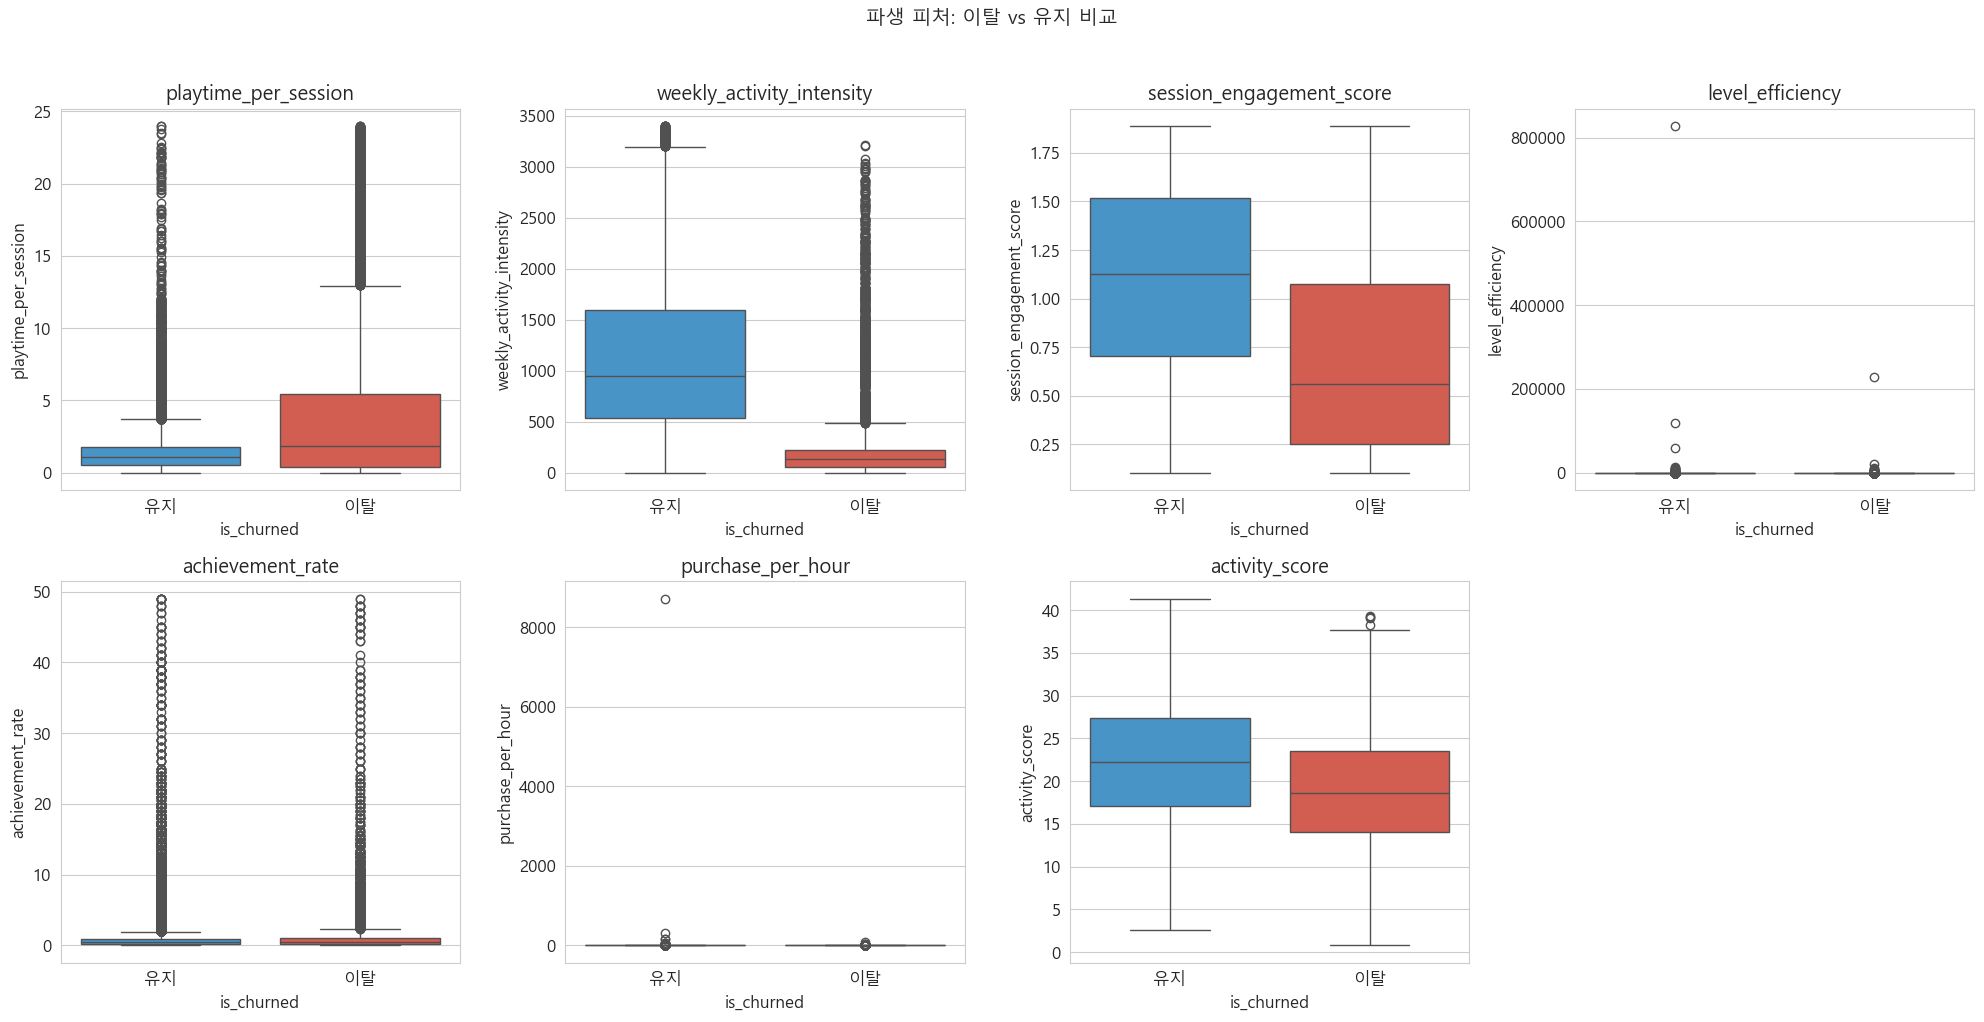

In [13]:
from src.features.engineer import engineer_gaming_behavior_features

df_feat = engineer_gaming_behavior_features(df)

derived_cols = ['playtime_per_session', 'weekly_activity_intensity', 
                'session_engagement_score', 'level_efficiency', 
                'achievement_rate', 'purchase_per_hour', 'activity_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(derived_cols):
    ax = axes[i]
    sns.boxplot(data=df_feat, x='is_churned', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
    ax.set_xticklabels(['유지', '이탈'])
    ax.set_title(col)

axes[7].axis('off')
plt.suptitle('파생 피처: 이탈 vs 유지 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

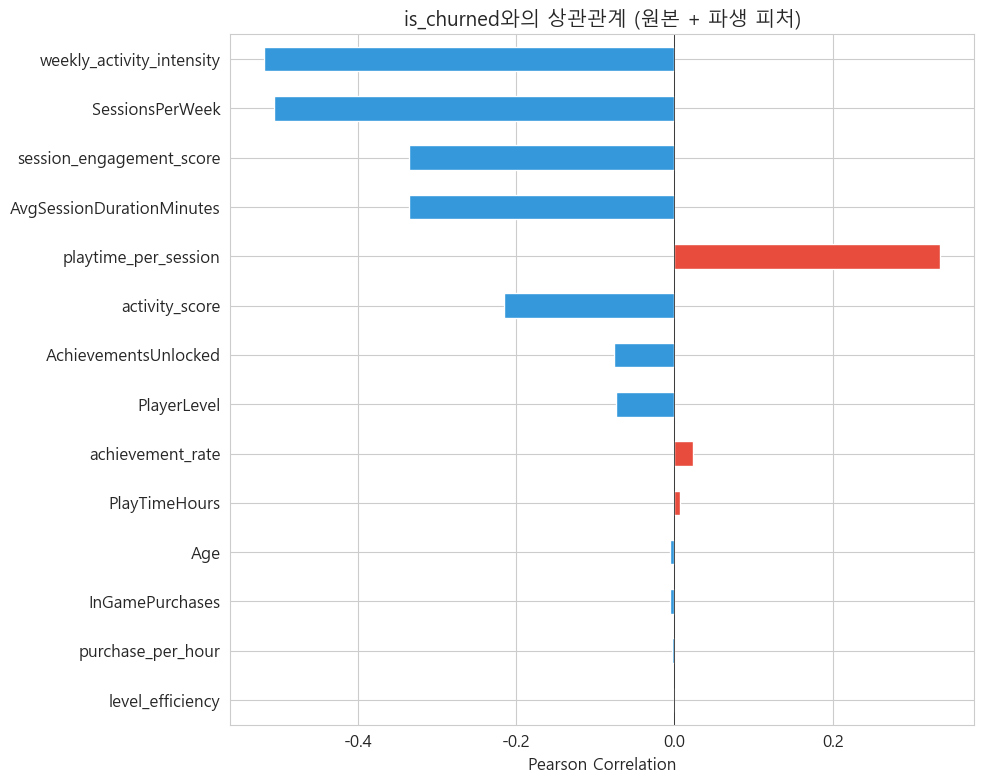

In [14]:
# 파생 피처 포함 상관관계 (is_churned 기준)
all_numeric = numeric_cols + ['InGamePurchases'] + derived_cols + ['is_churned']
corr_all = df_feat[all_numeric].corr()['is_churned'].drop('is_churned').sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_all.values]
corr_all.plot(kind='barh', ax=ax, color=colors)
ax.set_title('is_churned와의 상관관계 (원본 + 파생 피처)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. 다변량 분석 (Pairplot / 주요 피처 조합)

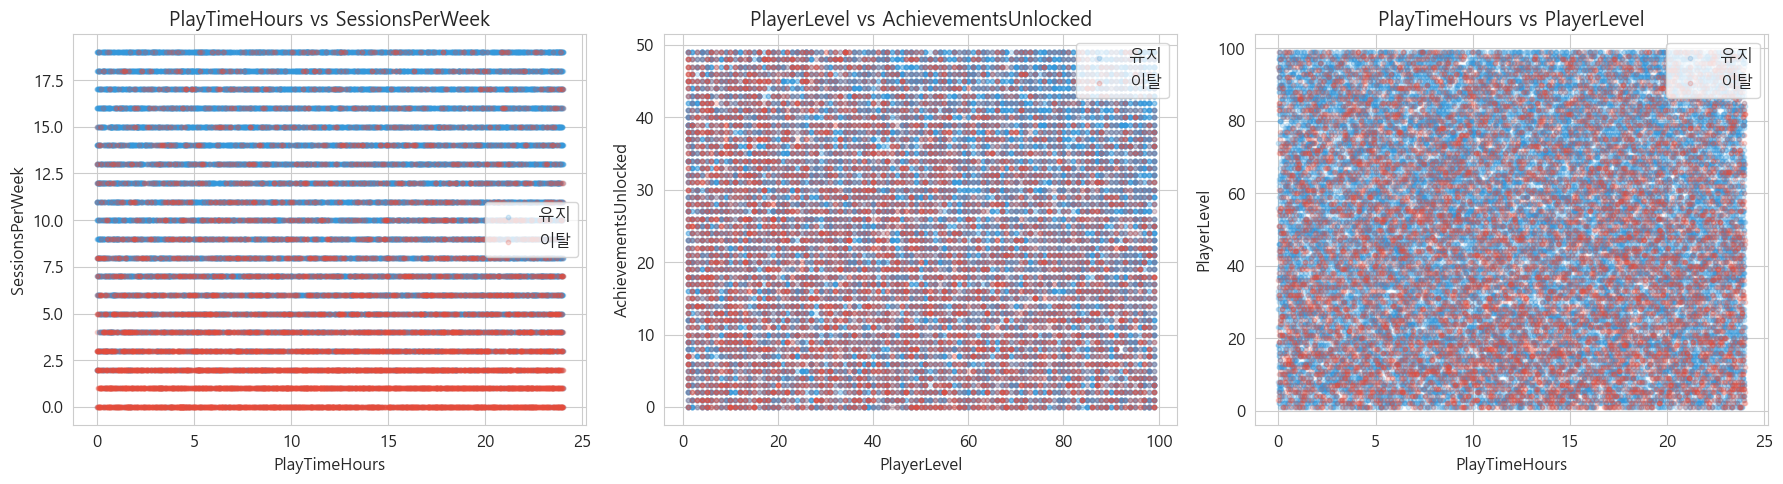

In [15]:
# 주요 피처 조합 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('PlayTimeHours', 'SessionsPerWeek'),
    ('PlayerLevel', 'AchievementsUnlocked'),
    ('PlayTimeHours', 'PlayerLevel'),
]

for ax, (x, y) in zip(axes, pairs):
    for label, color, name in [(0, '#3498db', '유지'), (1, '#e74c3c', '이탈')]:
        subset = df_feat[df_feat['is_churned'] == label]
        ax.scatter(subset[x], subset[y], c=color, alpha=0.2, s=10, label=name)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    ax.set_title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

## 9. 인게임 구매 × 이탈 분석

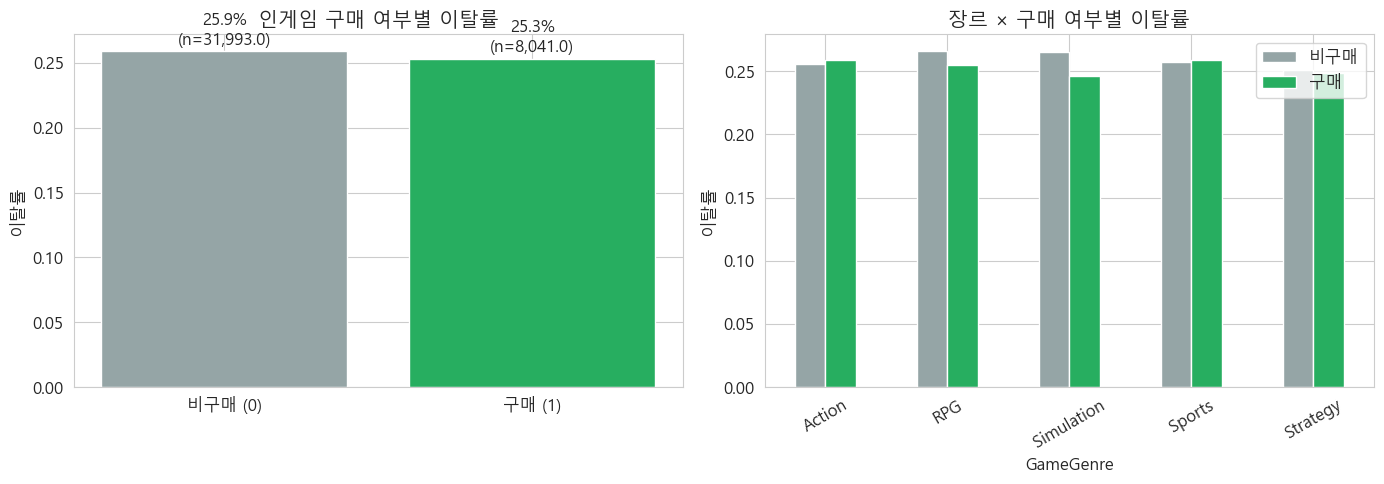

In [16]:
# InGamePurchases(0/1) × 이탈률
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 구매 유저 vs 비구매 유저 이탈률
purchase_churn = df.groupby('InGamePurchases')['is_churned'].agg(['mean', 'count'])
purchase_churn.columns = ['이탈률', '유저수']
bars = axes[0].bar(['비구매 (0)', '구매 (1)'], purchase_churn['이탈률'], color=['#95a5a6', '#27ae60'])
axes[0].set_title('인게임 구매 여부별 이탈률')
axes[0].set_ylabel('이탈률')
for bar, (_, row) in zip(bars, purchase_churn.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{row["이탈률"]:.1%}\n(n={row["유저수"]:,})', ha='center')

# 구매 여부 × 장르별 이탈률
cross = df.groupby(['GameGenre', 'InGamePurchases'])['is_churned'].mean().unstack()
cross.columns = ['비구매', '구매']
cross.plot(kind='bar', ax=axes[1], color=['#95a5a6', '#27ae60'])
axes[1].set_title('장르 × 구매 여부별 이탈률')
axes[1].set_ylabel('이탈률')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 10. 핵심 인사이트 정리

In [17]:
# 이탈 그룹별 주요 지표 요약
summary_table = df_feat.groupby('is_churned')[
    numeric_cols + ['InGamePurchases'] + derived_cols
].mean().T

summary_table.columns = ['유지 (평균)', '이탈 (평균)']
summary_table['차이'] = summary_table['이탈 (평균)'] - summary_table['유지 (평균)']
summary_table['차이(%)'] = (summary_table['차이'] / summary_table['유지 (평균)'] * 100)

print("=== 이탈 vs 유지 그룹 주요 지표 비교 ===\n")
print(summary_table.round(3).to_string())

=== 이탈 vs 유지 그룹 주요 지표 비교 ===

                            유지 (평균)  이탈 (평균)       차이    차이(%)
Age                          32.026   31.897   -0.129   -0.402
PlayTimeHours                11.996   12.105    0.109    0.905
SessionsPerWeek              11.189    4.531   -6.658  -59.509
AvgSessionDurationMinutes   104.491   66.882  -37.609  -35.992
PlayerLevel                  50.891   46.101   -4.789   -9.411
AchievementsUnlocked         25.175   22.662   -2.513   -9.982
InGamePurchases               0.202    0.197   -0.005   -2.365
playtime_per_session          1.495    4.019    2.523  168.762
weekly_activity_intensity  1133.224  219.825 -913.398  -80.602
session_engagement_score      1.102    0.706   -0.397  -35.992
level_efficiency             52.013   41.541  -10.472  -20.133
achievement_rate              1.234    1.412    0.178   14.415
purchase_per_hour             0.381    0.066   -0.315  -82.762
activity_score               22.169   18.743   -3.425  -15.451


### EDA 결론\n\n**데이터 특성:**\n- 40,034명 유저, 이탈률 약 25.8% (EngagementLevel=Low 기준)\n- 결측치 없음, 이상치는 일부 수치형 변수에 존재\n\n**이탈 관련 주요 발견:**\n- (위 분석 결과에 따라 실행 후 작성)\n- 상관관계, 통계 검정, 파생 피처 분석 결과를 종합하여 정리\n\n**모델링 방향:**\n- 파생 피처가 원본보다 이탈 예측에 유용한지 확인 필요\n- 범주형 변수의 영향도 검토 (장르, 난이도 등)\n- 데이터 불균형 (약 74:26) → class weight 또는 SMOTE 고려